# 2-3 파이토치 고수준 API

본 노트북은 본문 2-3 절의 코드 예제([코드 2-7] ~ [코드 2-16])를 절 흐름 그대로 모은 것이다. `nn.Module` 을 상속한 퍼셉트론 모델 클래스를 정의하고, `nn.MSELoss` 손실 함수와 `optim.SGD` 옵티마이저를 사용해 2-2 절과 같은 AND 게이트 시뮬레이터를 고수준 API 로 다시 구현한다.

[코드 2-7]·[코드 2-8]·[코드 2-9] 는 설명용 코드 조각(잘못된 예, 모델 클래스 템플릿, 사용 패턴)이라 단독 실행 대상이 아니므로 마크다운으로 인용만 한다. 실행 가능한 셀은 [코드 2-10] 부터다.

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 2-7] 저자의 실수 (설명용 인용)

최적화는 파라미터의 값이 아니라 기울기(`.grad`)를 사용해야 한다. 다음은 `.grad` 를 빠뜨린 잘못된 코드 조각으로, 단독 실행 대상이 아니다.

```python
def optimizer(weights, bias, learning_rate):
    with torch.no_grad():
        weights -= learning_rate * weights     # (오류) .grad 누락
        bias -= learning_rate * bias           # (오류) .grad 누락
```

## [코드 2-8] 파이토치 모델 클래스 템플릿 (설명용 인용)

`nn.Module` 을 상속해 모델을 정의하는 일반 골격이다. 

```python
import torch.nn as nn

# 모든 파이토치 모델은 nn.Module을 상속한 파생 클래스로 정의
class TemplateModel(nn.Module):
    # 생성자 메서드: 필요한 인자를 전달받아 모델을 구성할 부품(계층 객체)을 정의
    def __init__(self, ...):
        # 부모 클래스(nn.Module)의 생성자를 가장 먼저 호출
        super().__init__()
        # 모델 초기화 및 모델이 사용하는 여러 부품의 객체를 정의        
        self.layer_1 = ...
        self.layer_2 = ...

    # forward() 메서드: 계층 객체를 데이터 흐름 순서대로 배치해 모델을 조립
    # x: 모델에 입력되는 데이터 인자 (여러 입력 인자 사용 가능)
    # 모델 인스턴스를 함수처럼 호출하면 forward() 메서드가 실행
    def forward(self, x): 
        # 입력 데이터는 forward() 메서드가 정의한 순서대로 계층 객체를 통과
        x = self.layer_1(x)
        x = self.layer_2(x)
        # 반환값: 계층 객체를 모두 통과한 모델의 출력
        return x
```

## [코드 2-9] 파이토치 모델의 사용

모델 인스턴스를 만들고, `print()` 로 구성 계층을 출력하고, 함수처럼 호출해 `forward()` 를 실행하는 사용 패턴이다. 이때 `model()`과 `model.forward()`는 다르므로 주의가 필요하다. 특별한 이유가 없는 한 `model.forward()`로 실행하지 않는다.

```python
model = TemplateModel(...)      # 모델 인스턴스 생성
# print(model): print() 함수로 모델을 출력하면 모델 부품(계층 객체)의 목록이 출력
model(input)                    # 모델 호출: model.forward(input) 호출
```

## 퍼셉트론 모델 클래스 정의

`nn.Linear`(선형/퍼셉트론 계층)와 `nn.Sigmoid`(활성화 계층)를 생성자에서 정의하고, `forward()` 에서 데이터 흐름 순서대로 배치해 모델을 조립한다.

In [3]:
# 코드 2-10 - 퍼셉트론 모델 클래스 정의

# 시그모이드 활성화 함수를 사용하는 퍼셉트론 모델
class Perceptron(nn.Module):
    # 생성자 메서드: 퍼셉트론 모델의 부품인 선형 계층과 시그모이드 활성화 함수 계층 정의
    def __init__(self, in_features, out_features):
        super().__init__()                  # 부모 클래스의 생성자 호출
        # nn.Linear: 가중치를 곱하고 편향을 더하는 선형 계층 클래스
        # 인자 이름을 생략한 nn.Linear(in_features, out_features)와 같음
        self.linear_layer = nn.Linear(in_features=in_features, out_features=out_features)
        # nn.Sigmoid: 시그모이드 활성화 계층 클래스
        self.activation = nn.Sigmoid()      

    # forward() 메서드: linear_layer -> activation 순서로 데이터 흐름을 정의해 모델 조립
    def forward(self, x):
        x = self.linear_layer(x)            # (4, 2) -> (4, 1)
        x = self.activation(x)              # (4, 1) -> (4, 1)
        # 순서대로 계층 객체를 통과한 데이터를 모델의 출력으로 반환        
        return x

## 모델 인스턴스 생성과 구성 객체 출력

모델 인스턴스를 만들고 `print()` 로 출력하면 생성자에서 정의한 계층 객체가 표시된다.

In [4]:
# 코드 2-11 - 모델 생성과 구성 계층 객체 출력

model = Perceptron(2, 1)    # 퍼셉트론 모델 객체 생성
print(model)                # 퍼셉트론 모델을 구성하는 부품 출력

Perceptron(
  (linear_layer): Linear(in_features=2, out_features=1, bias=True)
  (activation): Sigmoid()
)


## 모델의 요약 정보

`torchinfo` 의 `summary()` 함수로 입력 형태에 따른 각 계층의 출력 형태와 파라미터 수를 확인한다. 모델의 구조, 파라미터 수 등의 요약 정보를 보여주는 `torchinfo.summary()` 함수는 CUDA 등 하드웨어 가속기 환경에서는 자동으로 모델을 하드웨어 가속기 장치로 옮겨 버리기 때문에 `device` 인자를 지정해야 한다. 하드웨어 가속기 장치와 사용법에 대해서는 5장에서 자세히 설명한다.

In [5]:
# 코드 2-12 - 모델의 요약 정보

summary(model, input_size=(4, 2), device=torch.device('cpu'))   # 모델의 요약 정보 출력

Layer (type:depth-idx)                   Output Shape              Param #
Perceptron                               [4, 1]                    --
├─Linear: 1-1                            [4, 1]                    3
├─Sigmoid: 1-2                           [4, 1]                    --
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## 모델의 예측값 계산과 입출력 텐서 형태

2-2 절과 같은 AND 게이트 입력 `X` 를 준비해 모델에 통과시키고, 입력과 출력의 형태 변화를 확인한다.

In [6]:
# 참고 - AND 게이트 데이터 (이전 절 [코드 2-1] 과 동일)
X = torch.tensor([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
Y_true = torch.tensor([[0.], [0.], [0.], [1.]])

In [7]:
# 코드 2-13 - 모델의 예측값 계산과 모델 입출력 텐서의 형태

Y_pred = model(X)           # 모델의 예측 결과 계산 (X: AND 게이트 시뮬레이터 입력값)
print(f'입력 형태: {X.shape} -> 출력 형태: {Y_pred.shape}')

입력 형태: torch.Size([4, 2]) -> 출력 형태: torch.Size([4, 1])


## 손실 함수 생성과 사용

직접 구현했던 평균제곱오차 손실 함수를 `nn.MSELoss` 클래스로 만든다. 계산된 손실은 스칼라 텐서이며, `grad_fn` 으로 어떤 연산이 이 텐서를 만들었는지 알 수 있다.

In [8]:
# 코드 2-14 - 손실 함수의 생성과 사용

criterion = nn.MSELoss()            # nn.MSELoss 평균제곱오차 손실 함수 생성
loss = criterion(Y_pred, Y_true)    # 예측값(Y_pred)과 정답(Y_true)의 오차를 집계해 손실 계산
print(loss)                         

tensor(0.2507, grad_fn=<MseLossBackward0>)


`grad_fn=<MseLossBackward0>` 표시는 자동 미분 그래프에서 어떤 연산 함수가 이 텐서를 만들었는지를 알려 준다. 손실 값을 정수·실수로 쓰려면 `loss.item()`, 학습과 무관하게 사용하려면 `loss.detach()` 로 연산 그래프에서 분리한다.

## SGD 옵티마이저 생성

`optim.SGD` 에 학습 대상 파라미터(`model.parameters()`)와 학습률(`lr`)을 지정해 옵티마이저를 만든다.

In [9]:
# 코드 2-15 - SGD 옵티마이저 생성

LR = 0.1                                            # 학습률
optimizer = optim.SGD(model.parameters(), lr=LR)    # SGD 옵티마이저 생성

## 고수준 API 를 사용하는 학습 루프

기존 학습 루프와 다른 점은 (1) `model.train()` 으로 학습 모드 선언, (2) `optimizer.zero_grad()` 로 기울기 초기화, (3) `optimizer.step()` 으로 파라미터 최적화하는 것이다.

    epoch         손실           w1           w2            b     시간
   1/1000       0.2507         0.54         0.58        -0.18     0:00
 100/1000       0.1461         0.53         0.56        -1.09     0:00
 200/1000       0.1229         0.76         0.78        -1.45     0:00
 300/1000       0.1066         0.97         0.98        -1.72     0:00
 400/1000       0.0942         1.15         1.16        -1.96     0:00
 500/1000       0.0844         1.31         1.32        -2.18     0:00
 600/1000       0.0764         1.46         1.46        -2.38     0:00
 700/1000       0.0698         1.59         1.59        -2.56     0:00
 800/1000       0.0641         1.71         1.71        -2.73     0:00
 900/1000       0.0592         1.82         1.82        -2.88     0:00
1000/1000       0.0550         1.92         1.92        -3.03     0:00
----------------------------------------------------------------------
전체 학습 시간 0:00


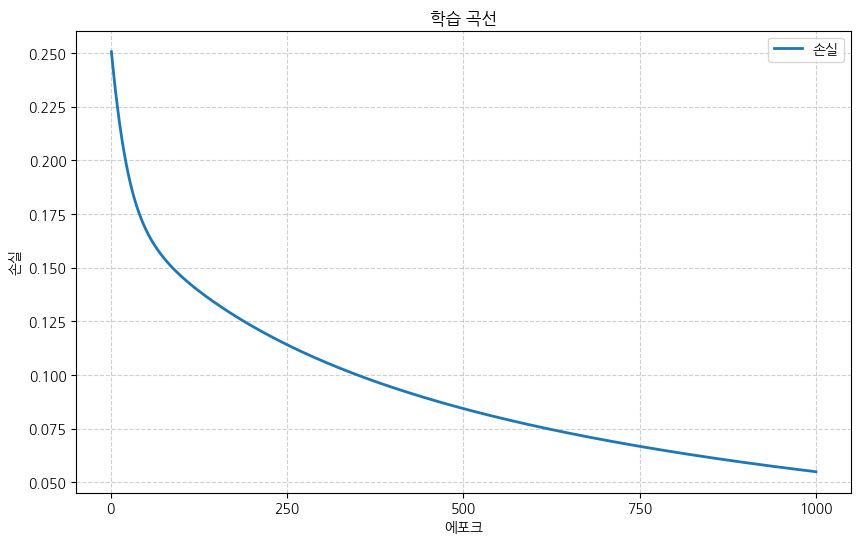

In [10]:
# 코드 2-16 - SGD 옵티마이저를 사용하는 학습 루프
EPOCHS = 1000

# 학습 로그는 표준 학습 로거(common.EpochLogger)를 사용해 출력한다. 평가 데이터가 없는
# 예제이므로 열을 (손실, w1, w2, b)로 구성해 손실과 파라미터를 함께 추적한다.
log = common.EpochLogger(
    EPOCHS,
    columns=('손실', 'w1', 'w2', 'b'),
    formats=('{:.4f}', '{:.2f}', '{:.2f}', '{:.2f}'),
    minimize='손실',
)

model.train()                           # 학습 모드 선언
for epoch in range(EPOCHS):
    Y_pred = model(X)                   # 순전파
    loss = criterion(Y_pred, Y_true)    # 손실 계산
    optimizer.zero_grad()               # 기울기 초기화
    loss.backward()                     # 역전파
    optimizer.step()                    # 파라미터 최적화
    with torch.no_grad():               # 학습과 무관한 컨텍스트
        # nn.Linear 의 가중치/편향은 weight, bias 속성에 저장됨
        # weight: (out_features, in_features) 형태의 2차원 텐서
        # bias: (out_features,) 형태의 1차원 텐서
        weights = model.linear_layer.weight.detach()
        w1 = weights[0, 0].item()
        w2 = weights[0, 1].item()
        bias = model.linear_layer.bias.detach().item()
        # 에포크별 손실과 파라미터(w1, w2, b)를 표준 학습 로거에 저장
        log.row(epoch + 1, loss.item(), w1, w2, bias)

# 학습 로그 출력
log.summary()

# 학습 곡선(손실의 변화 그래프) 출력
log.plot(title='학습 곡선')

`model.train()` / `model.eval()` 은 학습 모드와 평가 모드를 전환하는 스위치다. 현재 모델의 두 계층(`nn.Linear`, `nn.Sigmoid`)은 두 모드의 동작이 같아 호출하지 않아도 결과는 같지만, 학습/평가 단계를 코드에 표시하는 길잡이 역할을 하므로 습관적으로 사용한다.

## 학습된 결정 경계 시각화

고수준 API 로 학습한 모델의 파라미터로 결정 경계를 그리고, AND 게이트 4개 샘플에 대한 분류 정확도를 확인한다.

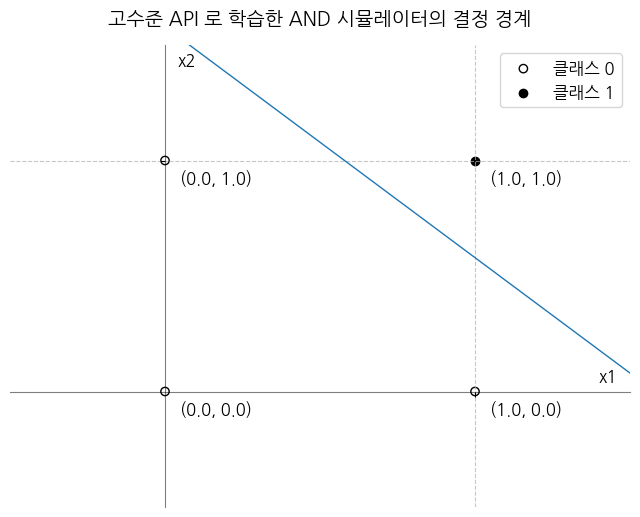

학습된 파라미터: w=(1.92, 1.92), b=-3.03
분류 정확도: 100.00%


In [11]:
# 참고 - 학습된 결정 경계 시각화
with torch.no_grad():
    weights = model.linear_layer.weight.detach()
    final_w1 = weights[0, 0].item()
    final_w2 = weights[0, 1].item()
    final_bias = model.linear_layer.bias.detach().item()

    Y_pred = model(X)
    Y_class = (Y_pred >= 0.5).float()
    accuracy = (Y_class == Y_true).float().mean().item() * 100

sample = (
    [0., 1., 0., 1.],   # x1
    [0., 0., 1., 1.],   # x2
    [0,  0,  0,  1 ],   # y
)

viz.plot_decision_boundary(
    sample=sample,
    params=[(final_w1, final_w2, final_bias)],
    title='고수준 API 로 학습한 AND 시뮬레이터의 결정 경계',
    x_label='x1', y_label='x2',
)

print(f'학습된 파라미터: w=({final_w1:.2f}, {final_w2:.2f}), b={final_bias:.2f}')
print(f'분류 정확도: {accuracy:.2f}%')

같은 AND 게이트 시뮬레이터를 (1) 자동 미분만 사용한 수동 구현(2-2 절)과 (2) 고수준 API(`nn.Module`, `nn.MSELoss`, `optim.SGD`)로 각각 만들어 보았다. 두 방식 모두 같은 분류 결과에 도달하지만, 고수준 API 는 더 간결하고 실수에 안전하다. 다음 3장에서는 퍼셉트론의 한계와 이를 극복하는 다층 퍼셉트론을 다룬다.